In [148]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.io.arff import loadarff 

### adult census dataset

In [ ]:
data, metadata = loadarff("../datasets/adult_census.arff")
adult_census = pd.DataFrame(data)
# removing b' '
for col in adult_census.select_dtypes(include="object"):
    adult_census[col] = adult_census[col].str.decode("utf-8")
adult_census

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25.0,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,<=50K
1,38.0,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K
2,28.0,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,>50K
3,44.0,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,>50K
4,18.0,?,103497.0,Some-college,10.0,Never-married,?,Own-child,White,Female,0.0,0.0,30.0,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27.0,Private,257302.0,Assoc-acdm,12.0,Married-civ-spouse,Tech-support,Wife,White,Female,0.0,0.0,38.0,United-States,<=50K
48838,40.0,Private,154374.0,HS-grad,9.0,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0.0,0.0,40.0,United-States,>50K
48839,58.0,Private,151910.0,HS-grad,9.0,Widowed,Adm-clerical,Unmarried,White,Female,0.0,0.0,40.0,United-States,<=50K
48840,22.0,Private,201490.0,HS-grad,9.0,Never-married,Adm-clerical,Own-child,White,Male,0.0,0.0,20.0,United-States,<=50K


In [150]:
print(f"{adult_census.shape[1] - 1} features")
adult_census['class'].value_counts()

14 features


class
<=50K    37155
>50K     11687
Name: count, dtype: int64

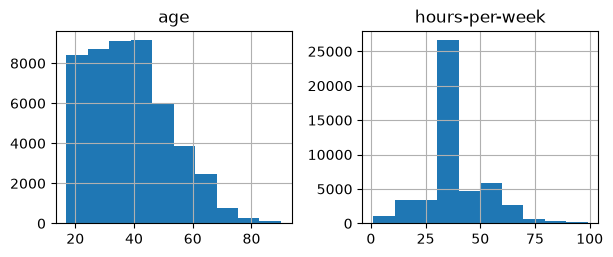

In [151]:
_ = adult_census[['age', 'hours-per-week']].hist(figsize=(7,2.5))

In [152]:
adult_census.groupby('sex')['class'].value_counts()

sex     class
Female  <=50K    14423
        >50K      1769
Male    <=50K    22732
        >50K      9918
Name: count, dtype: int64

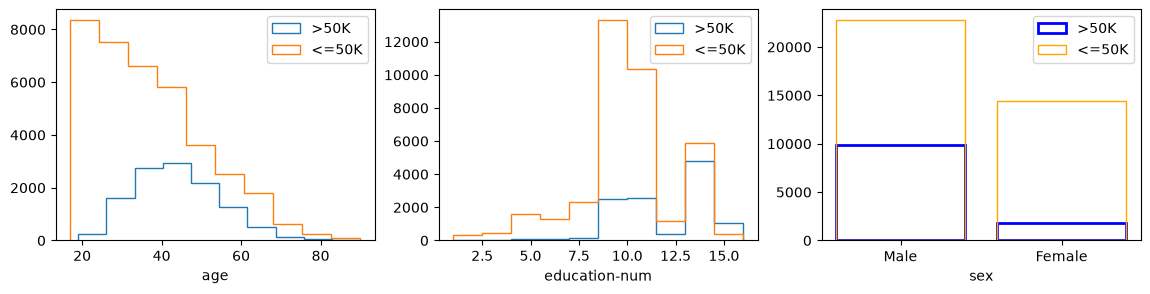

In [153]:
fig, ax = plt.subplots(1, 3, figsize=(14,3))
ax[0].hist(adult_census[adult_census['class']=='>50K']['age'], label='>50K', histtype="step")
ax[0].hist(adult_census[adult_census['class']=='<=50K']['age'], label='<=50K', histtype="step")
ax[0].set_xlabel('age')
ax[0].legend()
ax[1].hist(adult_census[adult_census['class']=='>50K']['education-num'], label='>50K', histtype="step")
ax[1].hist(adult_census[adult_census['class']=='<=50K']['education-num'], label='<=50K', histtype="step")
ax[1].set_xlabel('education-num')
ax[1].legend()
ax[2].bar(['Male', 'Female'], adult_census[adult_census['class']=='>50K']['sex'].value_counts().values, fill=False, edgecolor='blue', label='>50K', linewidth=2)
ax[2].bar(['Male', 'Female'], adult_census[adult_census['class']=='<=50K']['sex'].value_counts().values, fill=False, edgecolor='orange', label='<=50K')
ax[2].set_xlabel('sex')
ax[2].legend()

In [154]:
print(pd.crosstab(
    index=adult_census["education"], columns=adult_census["education-num"]
))
# 'education-num' feature is redundant
# adult_census = adult_census.drop(columns='education-num')

education-num  1.0   2.0   3.0   4.0   5.0   6.0   7.0   8.0    9.0    10.0  \
education                                                                     
10th              0     0     0     0     0  1389     0     0      0      0   
11th              0     0     0     0     0     0  1812     0      0      0   
12th              0     0     0     0     0     0     0   657      0      0   
1st-4th           0   247     0     0     0     0     0     0      0      0   
5th-6th           0     0   509     0     0     0     0     0      0      0   
7th-8th           0     0     0   955     0     0     0     0      0      0   
9th               0     0     0     0   756     0     0     0      0      0   
Assoc-acdm        0     0     0     0     0     0     0     0      0      0   
Assoc-voc         0     0     0     0     0     0     0     0      0      0   
Bachelors         0     0     0     0     0     0     0     0      0      0   
Doctorate         0     0     0     0     0     0   

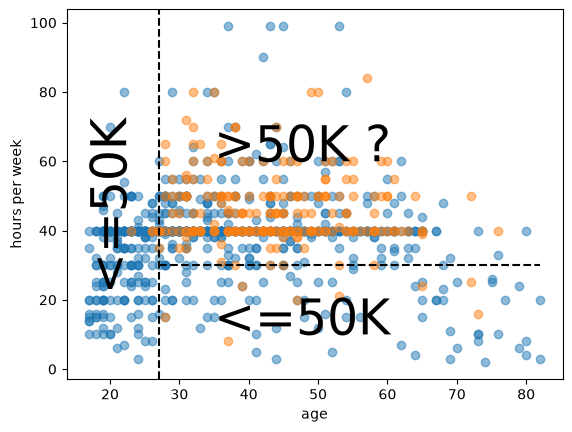

In [155]:
rng = np.random.default_rng(42)

adult_census_sample = adult_census.iloc[
    rng.choice(len(adult_census), size=1000, replace=False)
]

plt.scatter(
    adult_census_sample[adult_census_sample['class'] == '<=50K']['age'],
    adult_census_sample[adult_census_sample['class'] == '<=50K']['hours-per-week'],
    alpha=0.5,
)

plt.scatter(
    adult_census_sample[adult_census_sample['class'] == '>50K']['age'],
    adult_census_sample[adult_census_sample['class'] == '>50K']['hours-per-week'],
    alpha=0.5,
)

plt.xlabel('age')
plt.ylabel('hours per week')

age_limit = 27
plt.axvline(x=age_limit, color="black", linestyle="--")

hours_per_week_limit = 30
plt.hlines(
    y=hours_per_week_limit,
    xmin=age_limit,
    xmax=adult_census_sample['age'].max(),
    color="black",
    linestyle="--",
)

plt.annotate("<=50K", (17, 25), rotation=90, fontsize=35)
plt.annotate("<=50K", (35, 10), fontsize=35)
_ = plt.annotate(">50K ?", (35, 60), fontsize=35)